# X6Y3 Q1 tune-up with LeeQ built-in experiments

Uses the standard `TransmonElement`, `SimpleDriveCollection` and pulse shapes from [example_setup.py](example_setup.py), with one built-in experiment per cell as in [TuneUpExample.ipynb](TuneUpExample.ipynb).

**Experiment cells take shots when executed.** Use the **LeeQ — Huracan experiments** kernel, run cells individually and inspect each result. Reload this notebook from disk before using the updated configuration; rerunning setup and DUT initialization creates the new pulse objects.

LeeQ handles X/X90 through its standard collection. `update=True` updates the in-memory DUT. The original LBNL notebook and X6Y3 YAML/ZIP remain reference files.

This copy selects **Q1** and uses Q1 values from the LBNL configuration, including resonator spectroscopy and readout settings. Saved Q0 outputs have been cleared. Open with its own LeeQ kernel and run cells individually.

## Load LeeQ and the Huracan setup

In [1]:
import os, sys
from pathlib import Path
import yaml

LEEQ_ROOT = Path('/local/data/projects/LeeQ-lbnl-qubic')
HARNESS_ROOT = Path('/local/data/projects/qubic_validation')
os.environ['LITELLM_LOCAL_MODEL_COST_MAP'] = 'True'
os.environ['LAB_CHRONICLE_LOG_DIR'] = str(HARNESS_ROOT / 'artifacts/x6y3/leeq-chronicle')
sys.path.insert(0, str(LEEQ_ROOT))
sys.path.append(str(HARNESS_ROOT / 'artifacts/x6y3/venv/lib/python3.11/site-packages'))

from leeq import setup
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from leeq.chronicle import Chronicle
from leeq.core.primitives.built_in.common import Delay
from leeq.utils.compatibility import prims
# This checkout's built-ins use the legacy Delay export.
prims.Delay = Delay
from leeq.experiments.experiments import ExperimentManager
from leeq.core.elements.built_in.qudit_transmon import TransmonElement
from leeq.setups.huracan import create_huracan_setup
from leeq.experiments.builtin import *

manager = ExperimentManager()
if 'Huracan-X6Y3' in manager.get_available_setup_names():
    huracan = manager.get_setup('Huracan-X6Y3')
else:
    huracan = create_huracan_setup('/local/data/artifacts/zcu216/20260903T_aa01c78f_rdrv230_d4_candidate/bits_aa01c78f/channel_config.json')
    manager.register_setup(huracan)
manager.set_default_setup(huracan.name)

with (HARNESS_ROOT / 'X6Y3/configs_new/config.yaml').open() as f:
    config = yaml.safe_load(f)
huracan.status.set_parameters(Engine_Batch_Size=1, Shot_Number=1024,
                              Shot_Period=config['reset']['passive']['delay'] * 1e6,
                              Acquisition_Type='IQ', Measurement_Basis=None,
                              Plot_Result_In_Jupyter=True, AIAutoInspectPlots=False)
if not Chronicle().is_recording():
    Chronicle().start_log('X6Y3-builtins')

[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [WARNING] [leeq.chronicle.chronicle] No active log. Execution not recorded.
[2026-09-29 08:14:03] [INFO] [leeq.chronicle.chronicle] Log started at /local/data/projects/qubic_validation/artifacts/x6y3/leeq-chronicle/caos/2026-09/2026-09-29/08.14.03X6Y3-builtins


In [2]:
from leeq.experiments.builtin import *

## Initialize standard LeeQ qubits

Use `blackman_drag` with `alpha=1e9` and `trunc=1.2`, and `square` readout, as in LeeQ's example setup. Frequencies, starting X amplitudes, 70 ns drive width, readout amplitudes and acquisition timing come from the LBNL YAML; LeeQ uses MHz and µs. Demodulation phase remains in the original radians.

These are **starting parameters for the new shapes**, not a calibrated conversion of FAST_DRAG. The example's `alpha=1e9` effectively turns off the derivative correction initially; it is not qcal's dimensionless `alpha`. Calibrate amplitude with Rabi and ping-pong, and tune DRAG separately if needed. `trunc=1.2` pads the 70 ns drive envelope to 84 ns.

The current Huracan firmware exposes Q0 and Q1. Readout and demodulation use standard square envelopes while retaining their separate LBNL widths and delay; rerun readout calibration for this configuration.

In [3]:
setup().status().set_param('Engine_Batch_Size',1)
setup().status().set_param("Shot_Number", 500)
setup().status().set_param("Shot_Period", 500)                                      ######################################

In [4]:
duts = {}
for q in (0, 1):
    ge = config['single_qubit'][q]['GE']
    x_pulse = next(p for p in ge['X']['pulse'] if p['env'] != 'virtualz')
    readout = config['readout'][q]
    demod = readout['demod']
    duts[f'Q{q}'] = TransmonElement(name=f'Q{q}', parameters={
        'lpb_collections': {
            'f01': {
                'type': 'SimpleDriveCollection',
                'freq': ge['freq'] / 1e6,
                'channel': 2 * q,
                'shape': 'blackman_drag',
                'amp': x_pulse['kwargs']['amp'],
                'phase': x_pulse['kwargs'].get('phase', 0.0),
                'width': x_pulse['time'] * 1e6,
                'alpha': 1e9,
                'trunc': 1.2,
            },
        },
        'measurement_primitives': {
            '0': {
                'type': 'SimpleDispersiveMeasurement',
                'freq': readout['freq'] / 1e6,
                'channel': 2 * q + 1,
                'shape': 'square',
                'amp': readout['amp'],
                'phase': 0.0,
                'width': readout['time'] * 1e6,
                'distinguishable_states': [0, 1],
                'demodulation': {
                    'freq': readout['freq'] / 1e6,
                    'shape': 'square',
                    'amp': 1.0,
                    'phase': demod['phase'],
                    'width': demod['time'] * 1e6,
                    'delay': demod['delay'] * 1e6,
                },
            },
        },
    })

In [17]:
dut = duts['Q1']     # Q1 tune-up
c1 = dut.get_c1('f01')
mprim = dut.get_measurement_prim_intlist(0)
dut.print_config_info()

<IPython.core.display.JSON object>

## Readout calibration

Run this first to install LeeQ's GMM measurement transform for the subsequent experiments.

In [ ]:
mprim = dut.get_measurement_prim_intlist(0)         # resonator measurement params
c1 = dut.get_c1('f01')                              # qubit pulse collection

ResonatorSweepTransmissionWithExtraInitialLPB(dut,
            start = config['readout'][1]['freq'] / 1e6 - 10,
            stop  = config['readout'][1]['freq'] / 1e6 + 10,
            step = 0.5,
            num_avs = 1000,
            rep_rate = 0.0,
            mp_width = 8,
            amp=0.03
)

  0%|          | 0/2 [00:00<?, ?it/s]

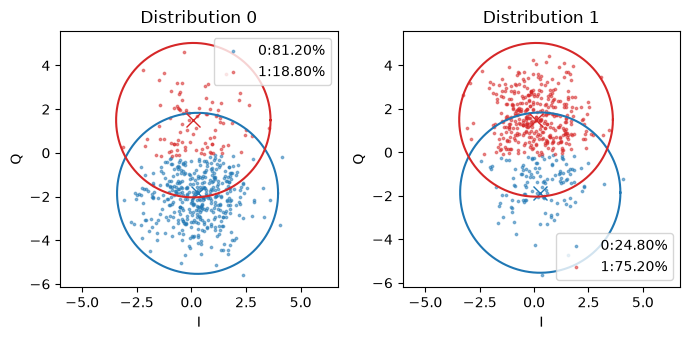

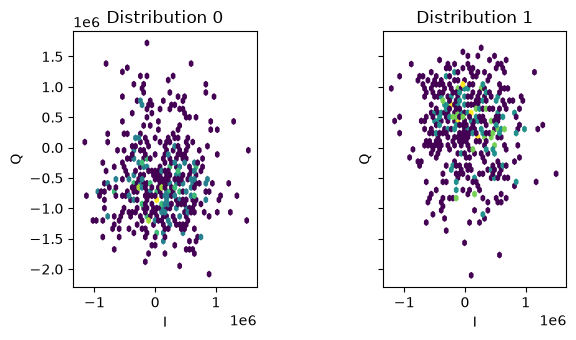

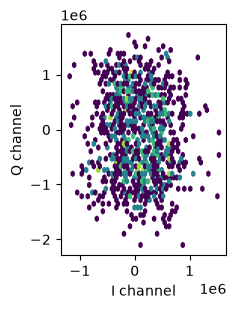

<IPython.core.display.JSON object>

In [6]:
calib = MeasurementCalibrationMultilevelGMM(dut=dut, mprim_index=0, sweep_lpb_list=(c1['I'], c1['X']))

  0%|          | 0/2 [00:00<?, ?it/s]

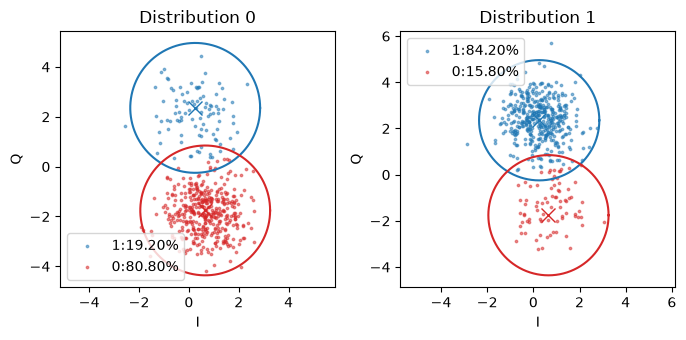

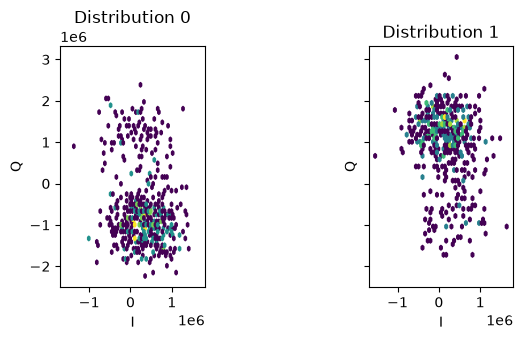

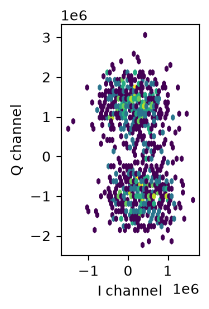

<IPython.core.display.JSON object>

In [33]:
mprim = dut.get_measurement_prim_intlist(0)          # resonator measurement params
c1 = dut.get_c1('f01')                               # qubit pulse collection

mprim.update_freq(config['readout'][1]['freq'] / 1e6)  # Q1 starting readout frequency  
mprim.update_pulse_args(amp=0.04, width=8)                   
lpb_scan = (dut.get_c1('f01')['I'], dut.get_c1('f01')['X'])
calib = MeasurementCalibrationMultilevelGMM(dut, mprim_index=0,sweep_lpb_list=lpb_scan)

## Rabi — initial amplitude calibration

LeeQ's built-in Rabi experiment sweeps a square probe and uses the configured Blackman envelope area to update the drive amplitude. Inspect the fit before proceeding to Ramsey and ping-pong. After improving the X pulse, rerun readout calibration if the initial state clusters were poorly separated.

  0%|          | 0/49 [00:00<?, ?it/s]

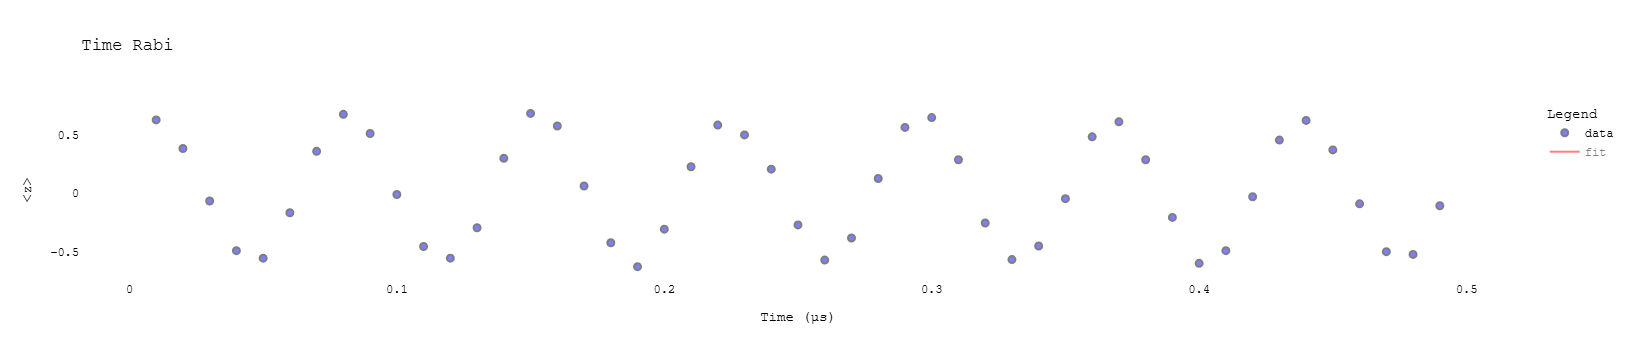

<IPython.core.display.JSON object>

In [8]:
rabi = NormalisedRabi(dut_qubit=dut, step=0.01, stop=0.5, amp=c1['X'].amp, update=True)

  0%|          | 0/49 [00:00<?, ?it/s]

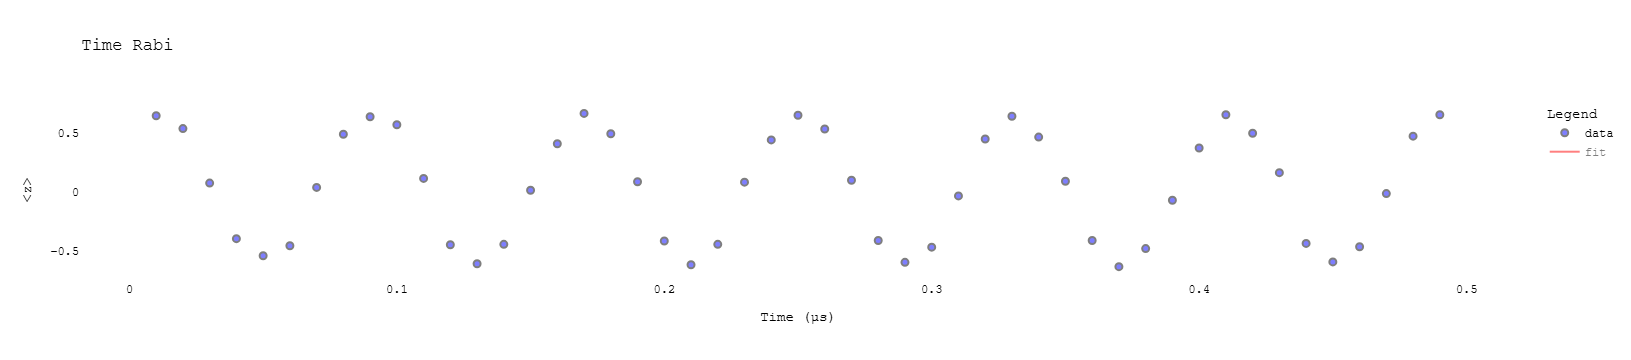

<IPython.core.display.JSON object>

In [9]:
rabi = NormalisedRabi(dut_qubit=dut, step=0.01, stop=0.5, amp=c1['X'].amp, update=True)

## Ramsey — 10 MHz offset, 0.3 µs window

  0%|          | 0/60 [00:00<?, ?it/s]

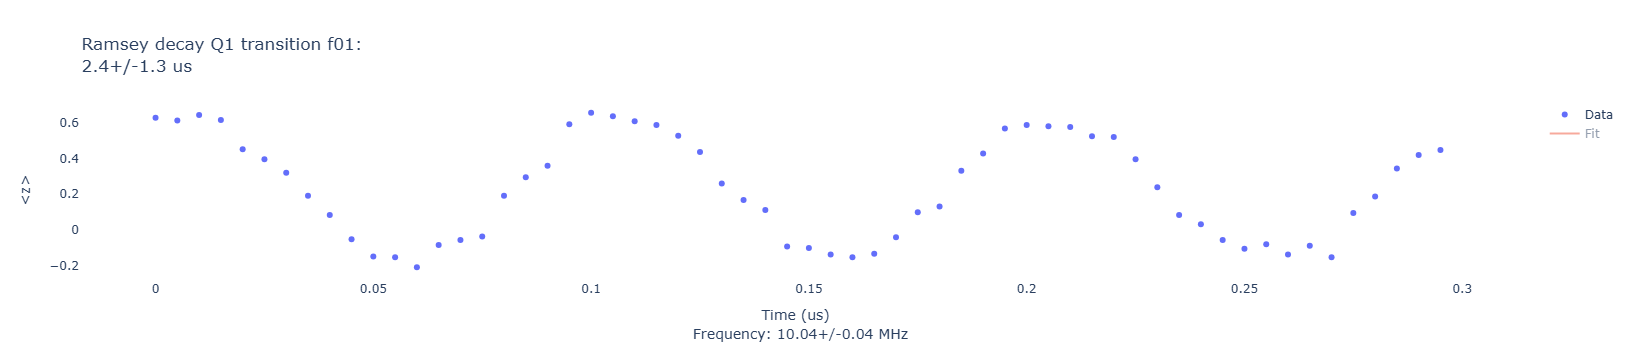

<IPython.core.display.JSON object>

In [10]:
ramsey_coarse = SimpleRamseyMultilevel(dut=dut, set_offset=10, stop=0.3, step=0.005, update=True)

## Ramsey — 1 MHz offset, 3 µs window

  0%|          | 0/60 [00:00<?, ?it/s]

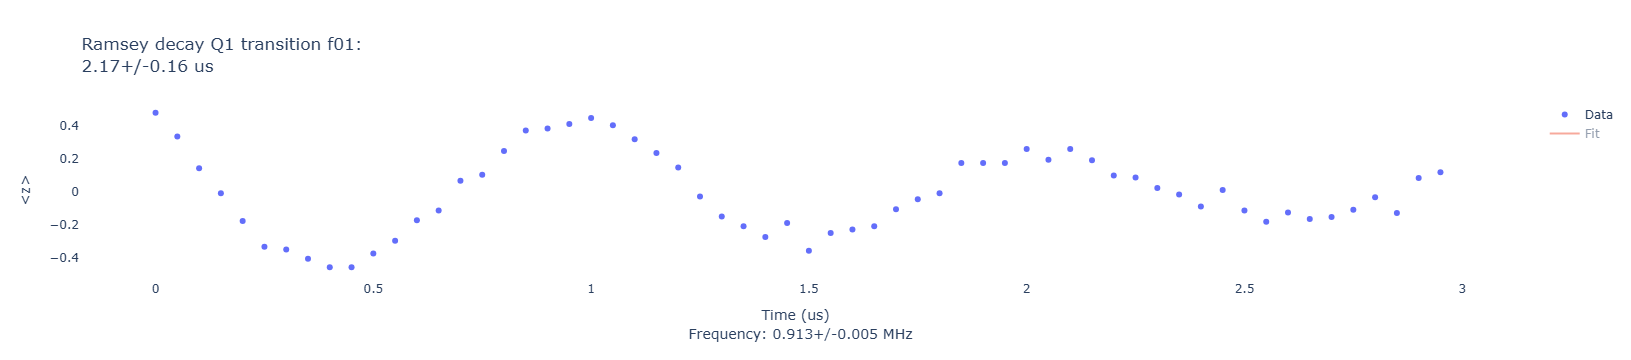

<IPython.core.display.JSON object>

In [11]:
ramsey_medium = SimpleRamseyMultilevel(dut=dut, set_offset=1, stop=3, step=0.05, update=True)

## Ramsey — 0.1 MHz offset, 30 µs window

Inspect the preceding fit before running this cell. The earlier Q0 fine scan was unreliable; do not assume a long-window fit is valid solely because it returned a number.

  0%|          | 0/60 [00:00<?, ?it/s]

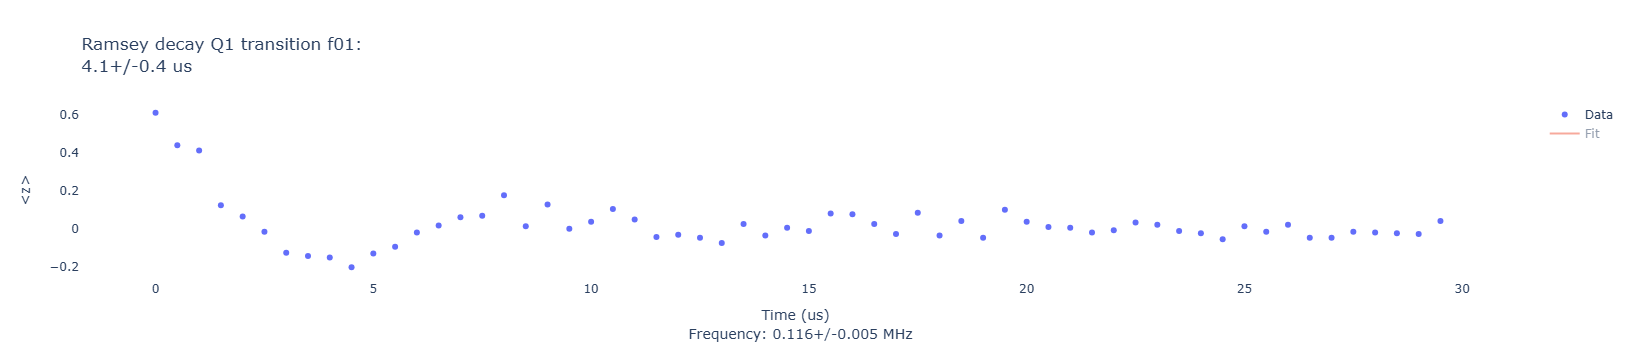

<IPython.core.display.JSON object>

In [12]:
ramsey_fine = SimpleRamseyMultilevel(dut=dut, set_offset=0.1, stop=30, step=0.5, update=True)

## Amplitude fine tuning with ping-pong

`AmpPingpongCalibrationSingleQubitMultilevel` is the current built-in amplitude tuner corresponding to the example's older `AmpTuneUpSingleQubitMultilevel` name. LeeQ updates the standard drive collection and handles X/X90. Start with three iterations; adjust the call if needed.

  0%|          | 0/4 [00:00<?, ?it/s]

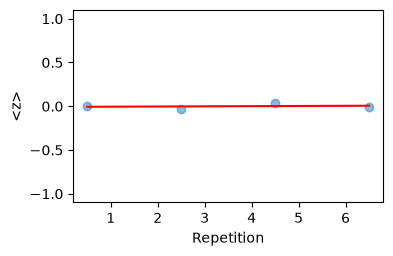

<IPython.core.display.JSON object>

  0%|          | 0/8 [00:00<?, ?it/s]

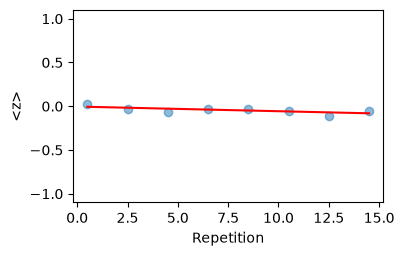

<IPython.core.display.JSON object>

  0%|          | 0/8 [00:00<?, ?it/s]

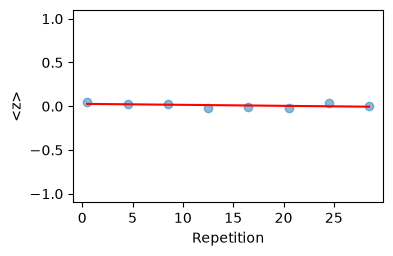

<IPython.core.display.JSON object>

  0%|          | 0/8 [00:00<?, ?it/s]

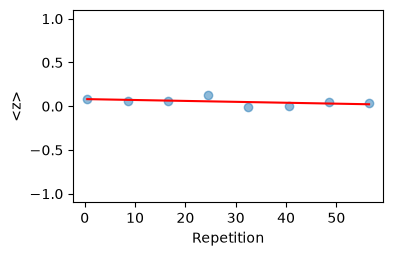

<IPython.core.display.JSON object>

  0%|          | 0/10 [00:00<?, ?it/s]

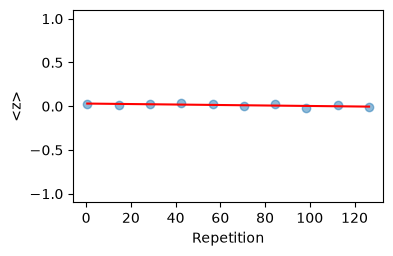

<IPython.core.display.JSON object>

  0%|          | 0/10 [00:00<?, ?it/s]

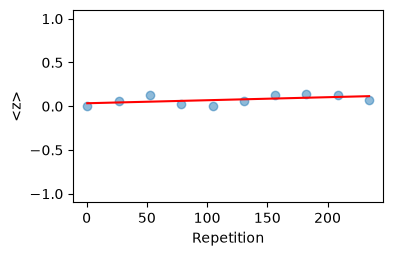

<IPython.core.display.JSON object>

  0%|          | 0/10 [00:00<?, ?it/s]

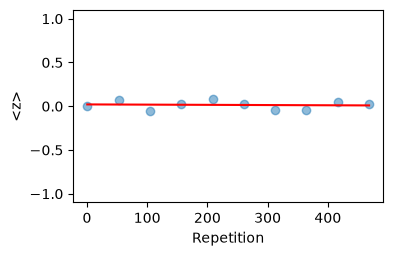

<IPython.core.display.JSON object>

  0%|          | 0/10 [00:00<?, ?it/s]

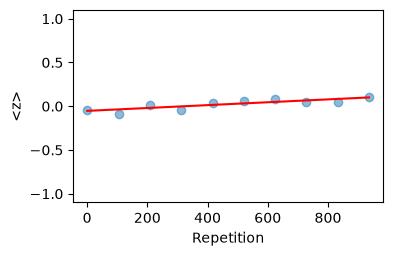

<IPython.core.display.JSON object>

  0%|          | 0/10 [00:00<?, ?it/s]

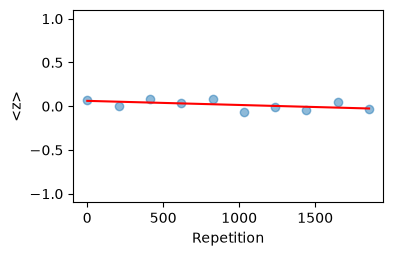

<IPython.core.display.JSON object>

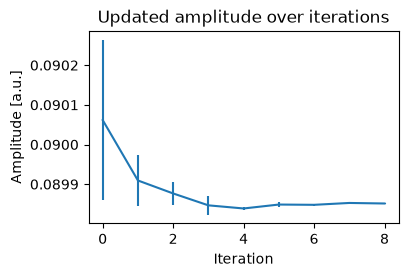

<IPython.core.display.JSON object>

In [13]:
pingpong = AmpPingpongCalibrationSingleQubitMultilevel(dut=dut)

## T1

  0%|          | 0/50 [00:00<?, ?it/s]

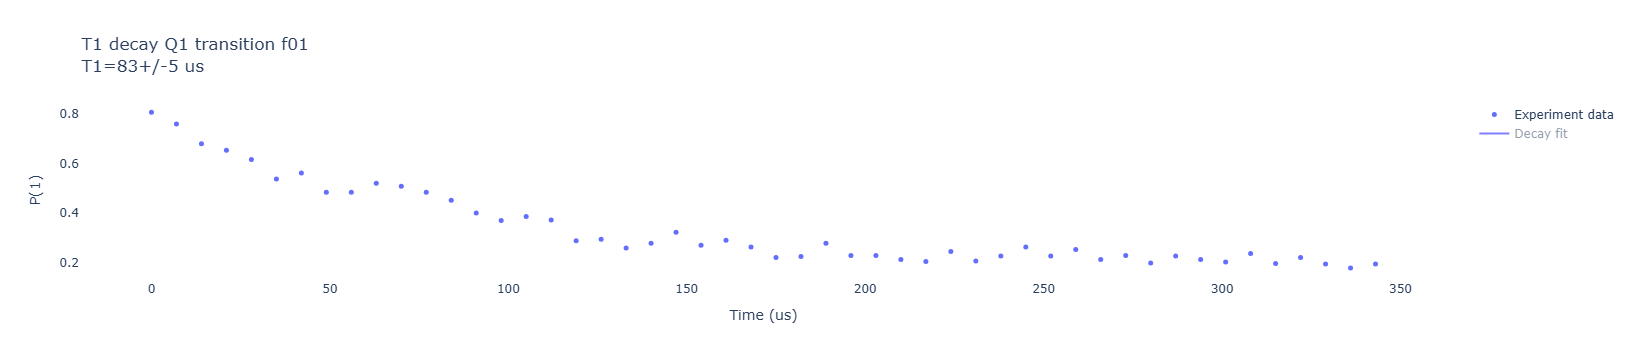

<IPython.core.display.JSON object>

In [14]:
t1 = SimpleT1(qubit=dut, time_length=350, time_resolution=7)

  0%|          | 0/60 [00:00<?, ?it/s]

/local/data/projects/LeeQ-lbnl-qubic/leeq/theory/fits/fit_exp.py:151: RuntimeWarning: overflow encountered in exp
  fit = amp * np.exp(-t / T) + offset
/local/data/projects/LeeQ-lbnl-qubic/leeq/theory/fits/fit_exp.py:152: RuntimeWarning: overflow encountered in square
  return np.sum((fit - z) ** 2) * 1e5


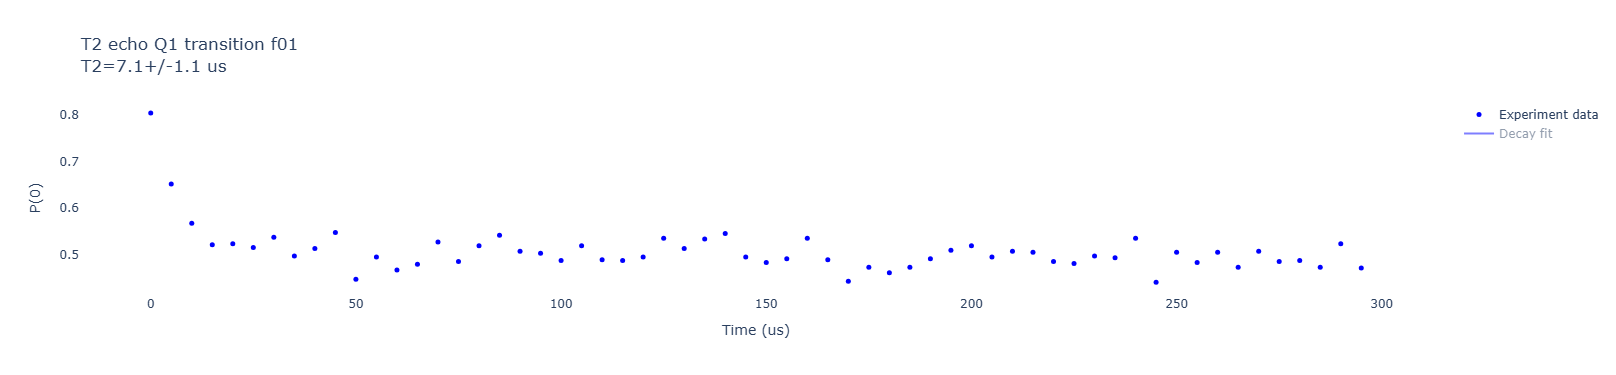

<IPython.core.display.JSON object>

<Experiment: SpinEchoMultiLevel>

In [15]:
SpinEchoMultiLevel(dut,free_evolution_time=300,time_resolution=5)


  0%|          | 0/200 [00:00<?, ?it/s]

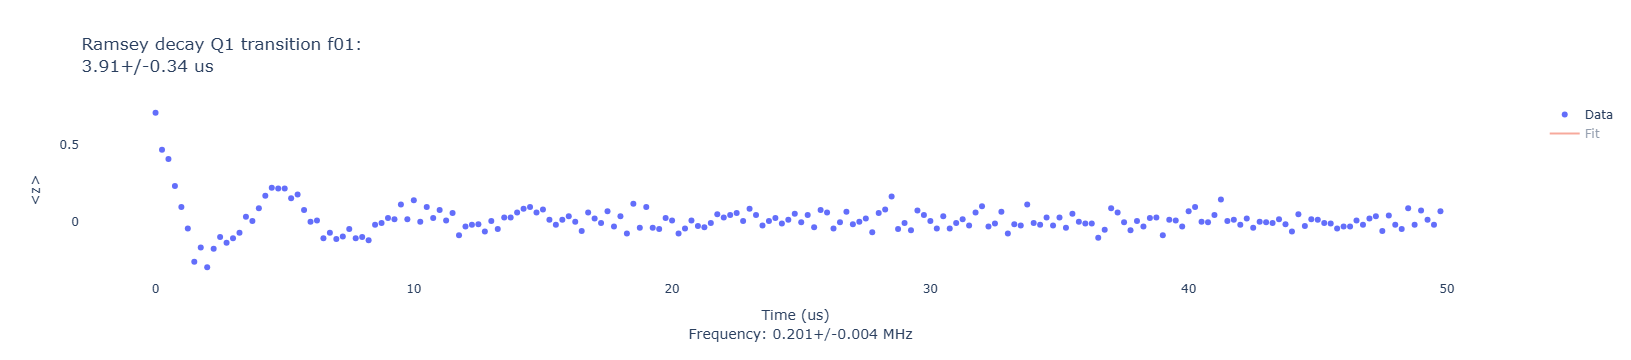

<IPython.core.display.JSON object>

In [16]:
ramsey = SimpleRamseyMultilevel(
    dut=dut,
    stop=50,
    step=0.25,
    set_offset=0.2
)

## Inspect the current parameters

Experiments display their own plots and record through LeeQ Chronicle. Inspect their result objects (`rabi`, `ramsey_coarse`, `ramsey_medium`, `ramsey_fine`, `pingpong`, `t1`) as needed.

In [ ]:
dut.print_config_info()

## Save reviewed parameters to the LeeQ calibration log

Optional: this saves a local LeeQ calibration log, leaving the original YAML/ZIP intact.

In [34]:
dut.save_calibration_log()

[2026-09-29 08:28:47] [WARNING] [leeq.utils.utils] LEEQ_CALIBRATION_LOG_PATH not found in environment variables. Using default path at /local/data/projects/LeeQ-lbnl-qubic/notebooks/RealSystem/calibration_logs.
